# Estudio y comparativa resultados distributed + neg out y high fixed

En este notebook vamos a analizar los resultados de la versión distribuida basada en complejidad que incluye la opción de ir quitando las variables con complejidad negativa (con un margen de tolerancia) y de ir fijando las que tienen un valor alto de complejidad. Este valor alto de complejidad es difícil de establecer porque siempre son valores bajitos y además varían en función de la medida de complejidad. Así, por ahora (y por temas computacionales) solo estamos ejecutando para kDN y fijándonos en sus valores. Además, debido a que es "más seguro" que las negativas son malas, damos más fuerza a esto. Es decir, si una variable toma valores negativos, se saca aunque previamente se hubiera fijado. Una vez tomas algún valor negativo estás totalmente fuera y no puedes volver a entrar. Pero si se fija la variable, sí puede volver a salir. Digamos que sacamos variables con más fuerza para ir limpiando.

En base a los resultados del notebook "Distributed_FS_Complexity_Analysis", ya solo aplicamos un método a la hora de obtener los resultados. Se ejecuta únicamente la opción "random choice". Luego el método es: tomar muestras bootstrap de variables e ir evaluando la complejidad siguiendo un esquema backward. La variable que sale en cada caso se escoge de manera aleatoria.

Aquí vamos tanto a estudiar los resultados de esta versión distribuida como a comparar su performance tanto en complejidad como en rendimiento con los métodos del SOTA. En todos los casos vamos a escoger el número k de variables como el número de variables informativas (sabemos cuál es porque estamos en el caso artificial). En nuestra versión distribuida hemos hecho un filtro previo de variables con correlación de Pearson superior a 0.9. Así, para que las comparaciones sean justas, hemos ejecutado los métodos del estado del arte tanto sin el filtro como con el filtro. Los métodos del SOTA con filtro tendrán un "_corr" en el nombre.

In [1]:
import copy
from sklearn import preprocessing
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from skrebate import ReliefF
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import glob
import re
from DistributedFS_Complexity import *

In [2]:
import os
os.chdir("..")
root_path = os.getcwd()

### Resultados distributed

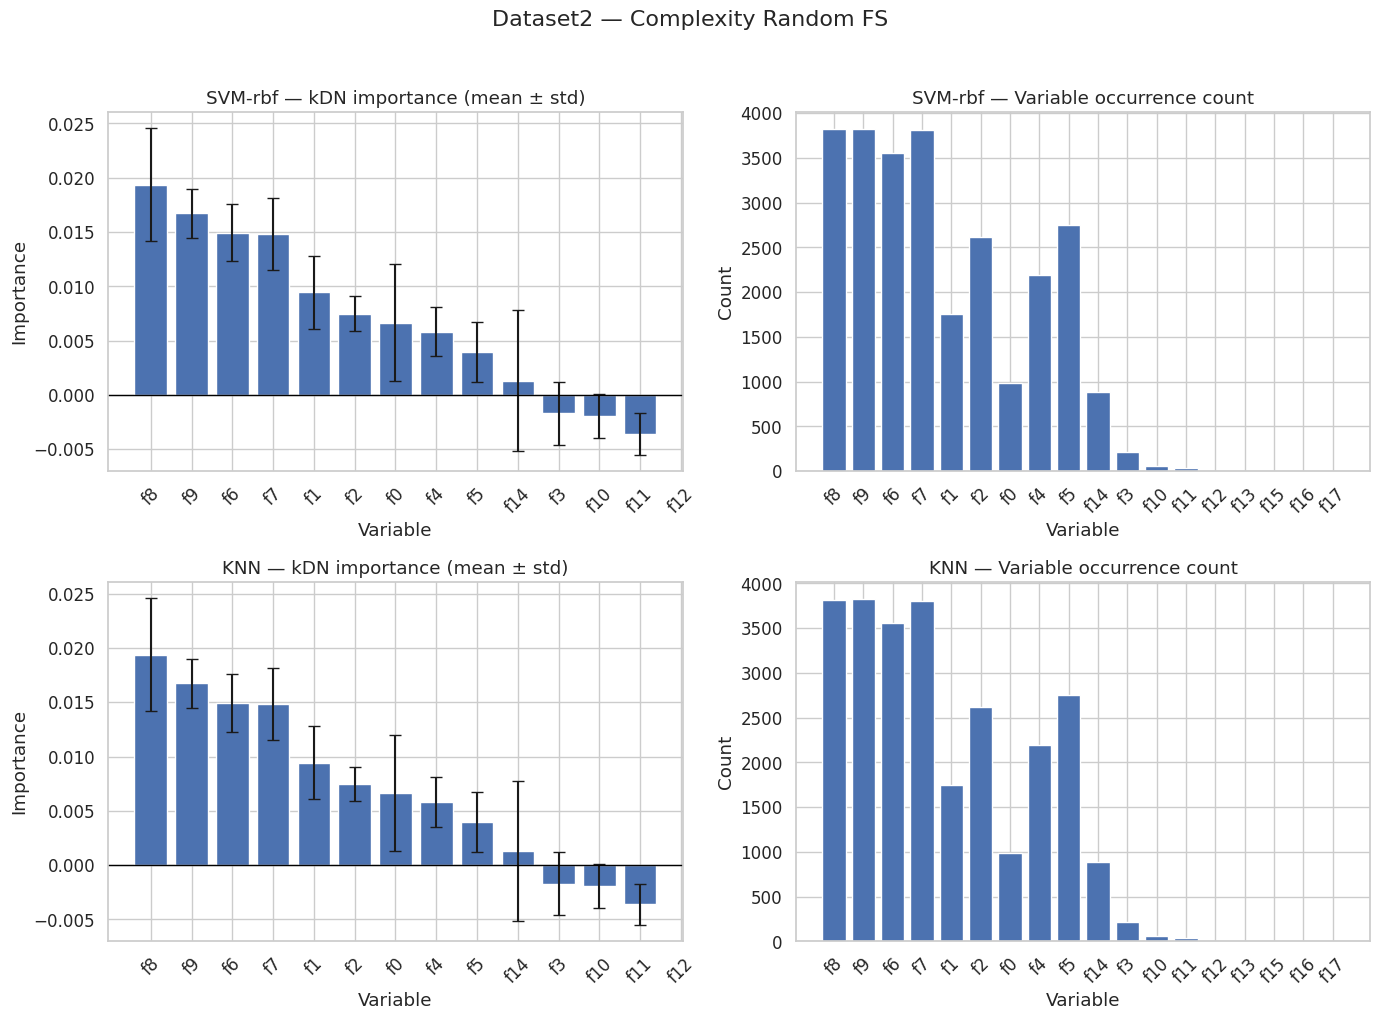

In [3]:
# Dataset 2
df_random = pd.read_csv("Results_FS_Distributed_CV/ArtificialDataset2_DistributedCVRandom_OutHigh_FeatureImportance_Folds.csv", index_col=0)

plot_complexity_importances_by_model(df_random, dataset_name="Dataset2")

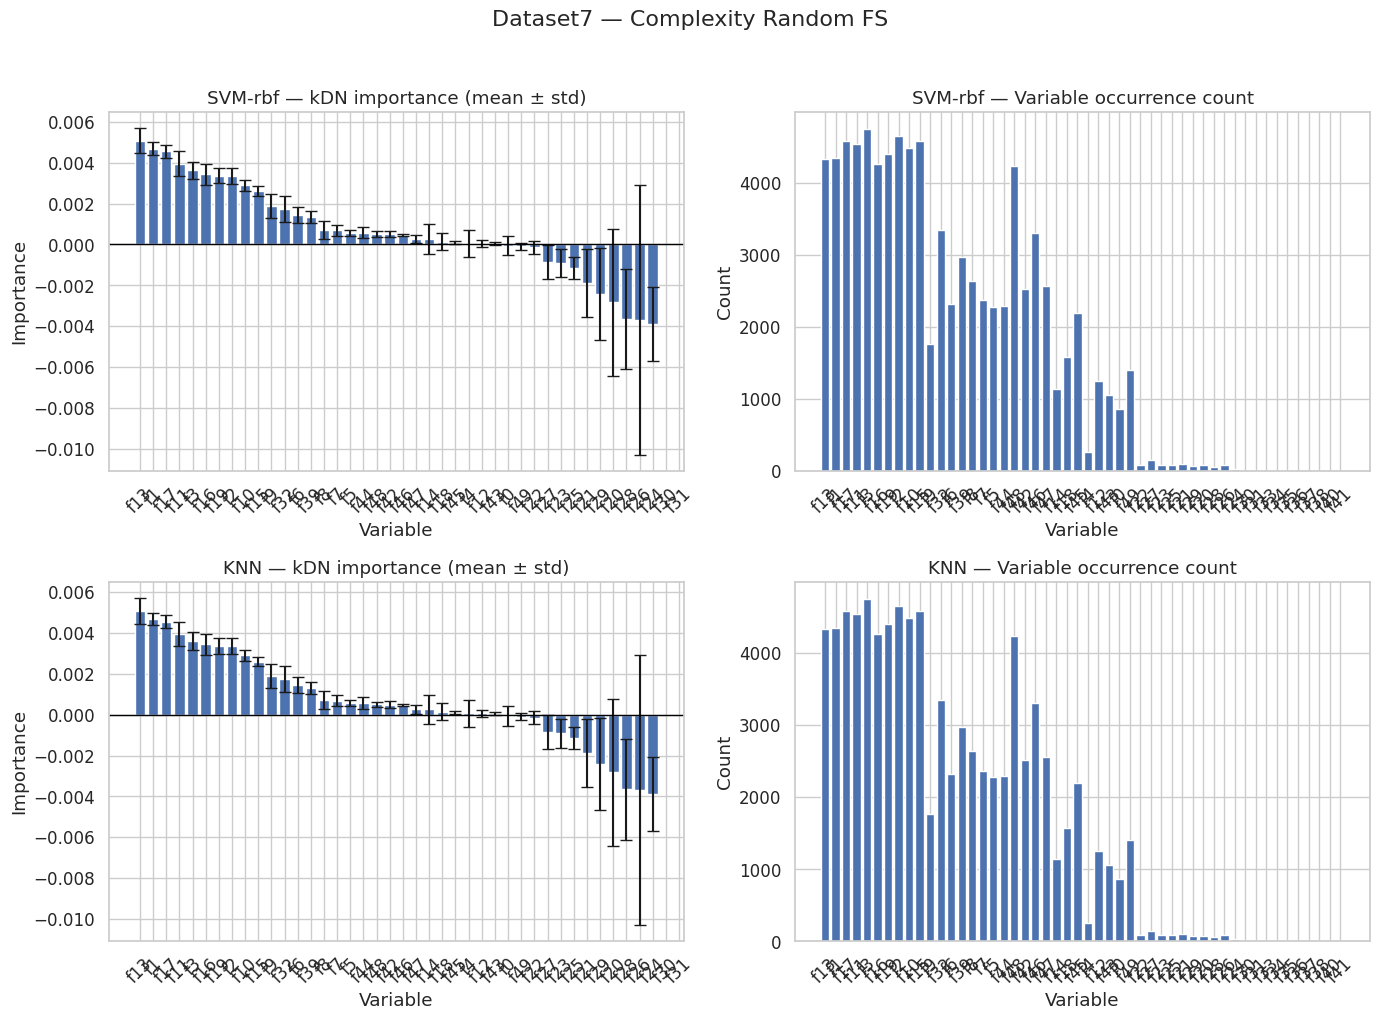

In [5]:
# Dataset  7
df_random = pd.read_csv("Results_FS_Distributed_CV/ArtificialDataset7_DistributedCVRandom_OutHigh_FeatureImportance_Folds.csv", index_col=0)

plot_complexity_importances_by_model(df_random, dataset_name="Dataset7")

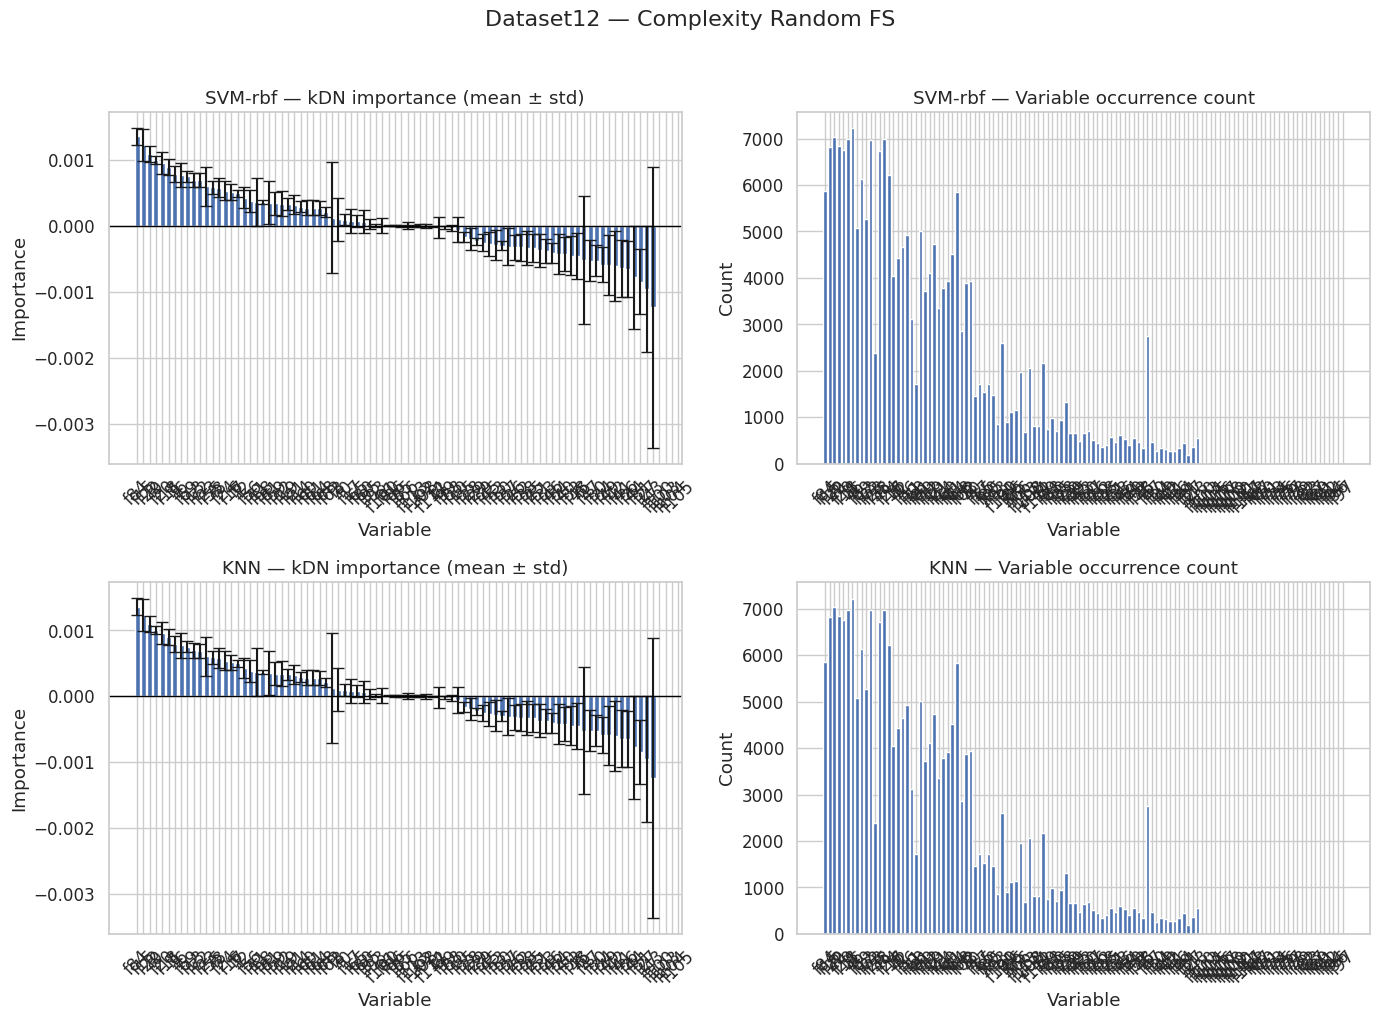

In [6]:
# Dataset 12
df_random = pd.read_csv("Results_FS_Distributed_CV/ArtificialDataset12_DistributedCVRandom_OutHigh_FeatureImportance_Folds.csv", index_col=0)

plot_complexity_importances_by_model(df_random, dataset_name="Dataset12")

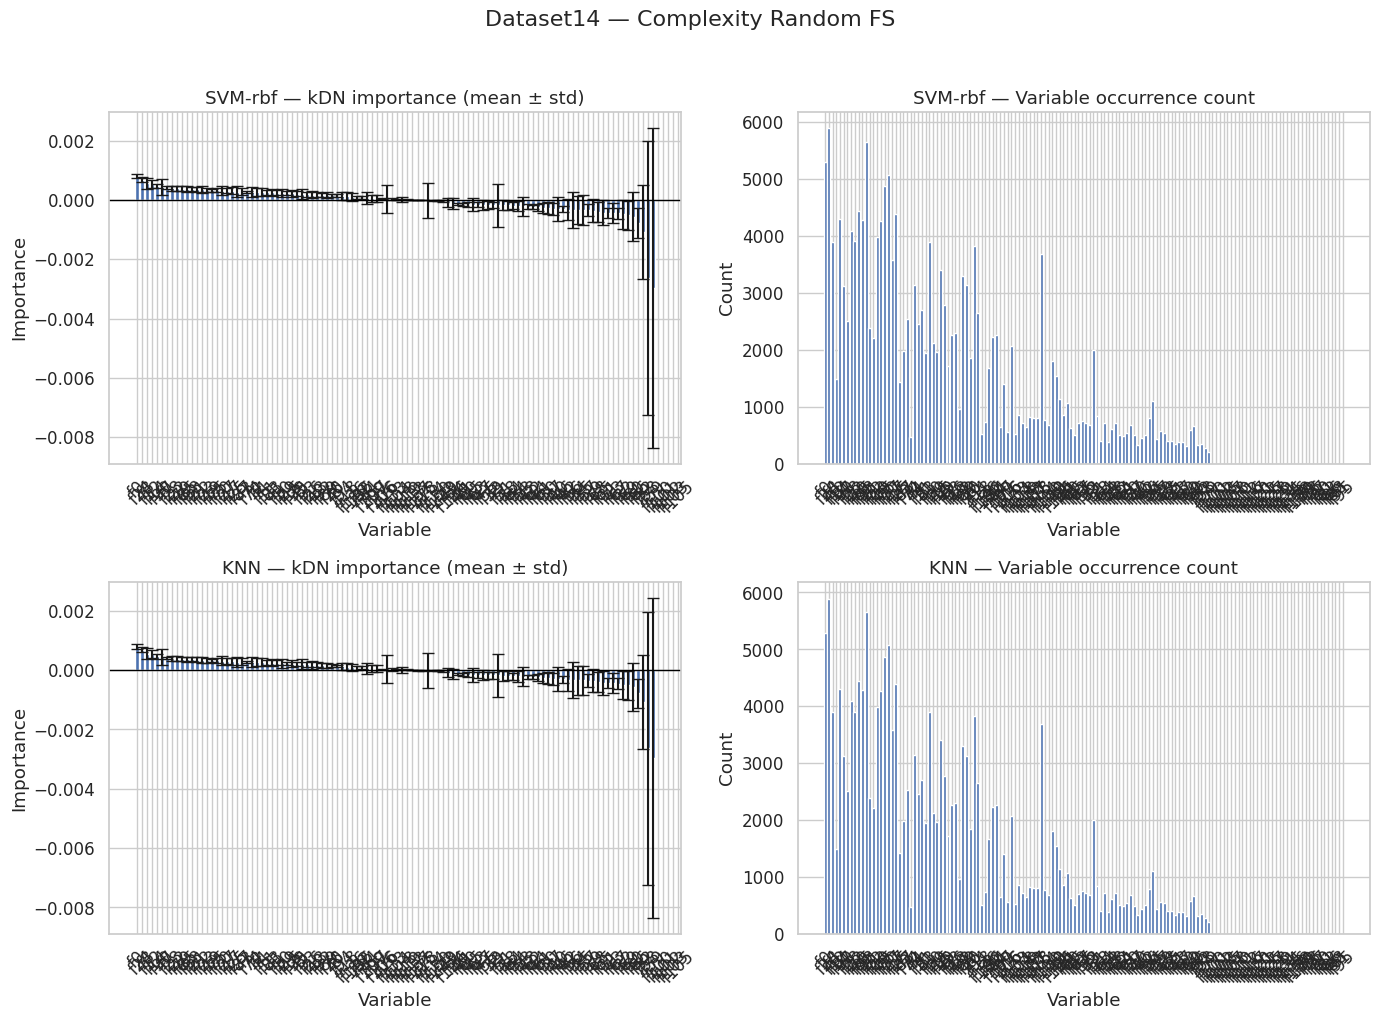

In [7]:
# # Dataset 14
df_random = pd.read_csv("Results_FS_Distributed_CV/ArtificialDataset14_DistributedCVRandom_OutHigh_FeatureImportance_Folds.csv", index_col=0)

plot_complexity_importances_by_model(df_random, dataset_name="Dataset14")

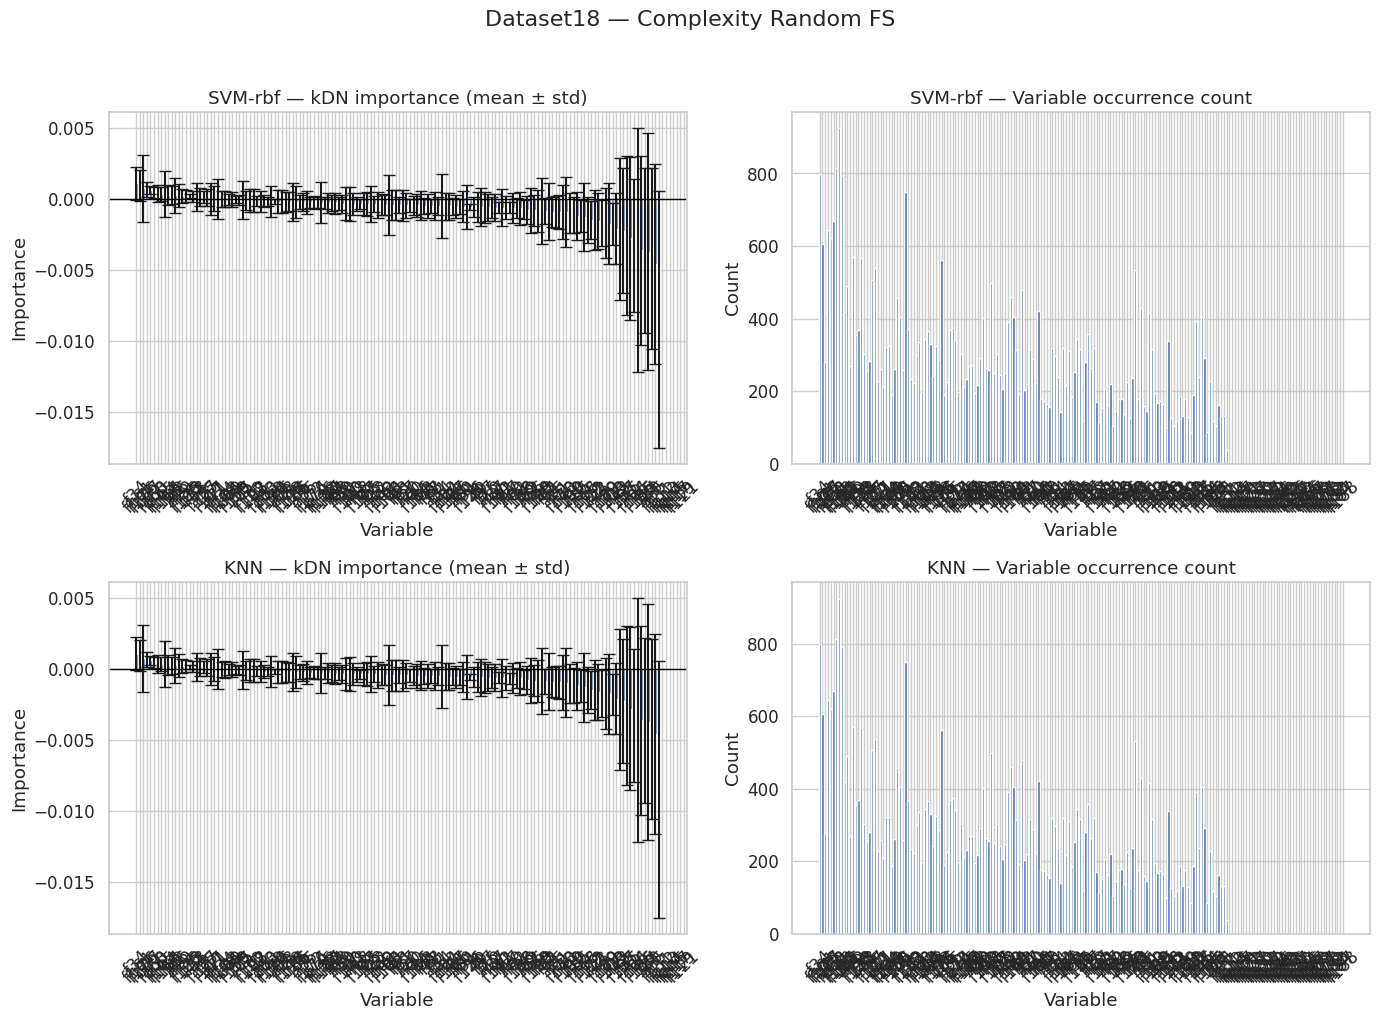

In [8]:
# # Dataset 18
df_random = pd.read_csv("Results_FS_Distributed_CV/ArtificialDataset18_DistributedCVRandom_OutHigh_FeatureImportance_Folds.csv", index_col=0)

plot_complexity_importances_by_model(df_random, dataset_name="Dataset18")

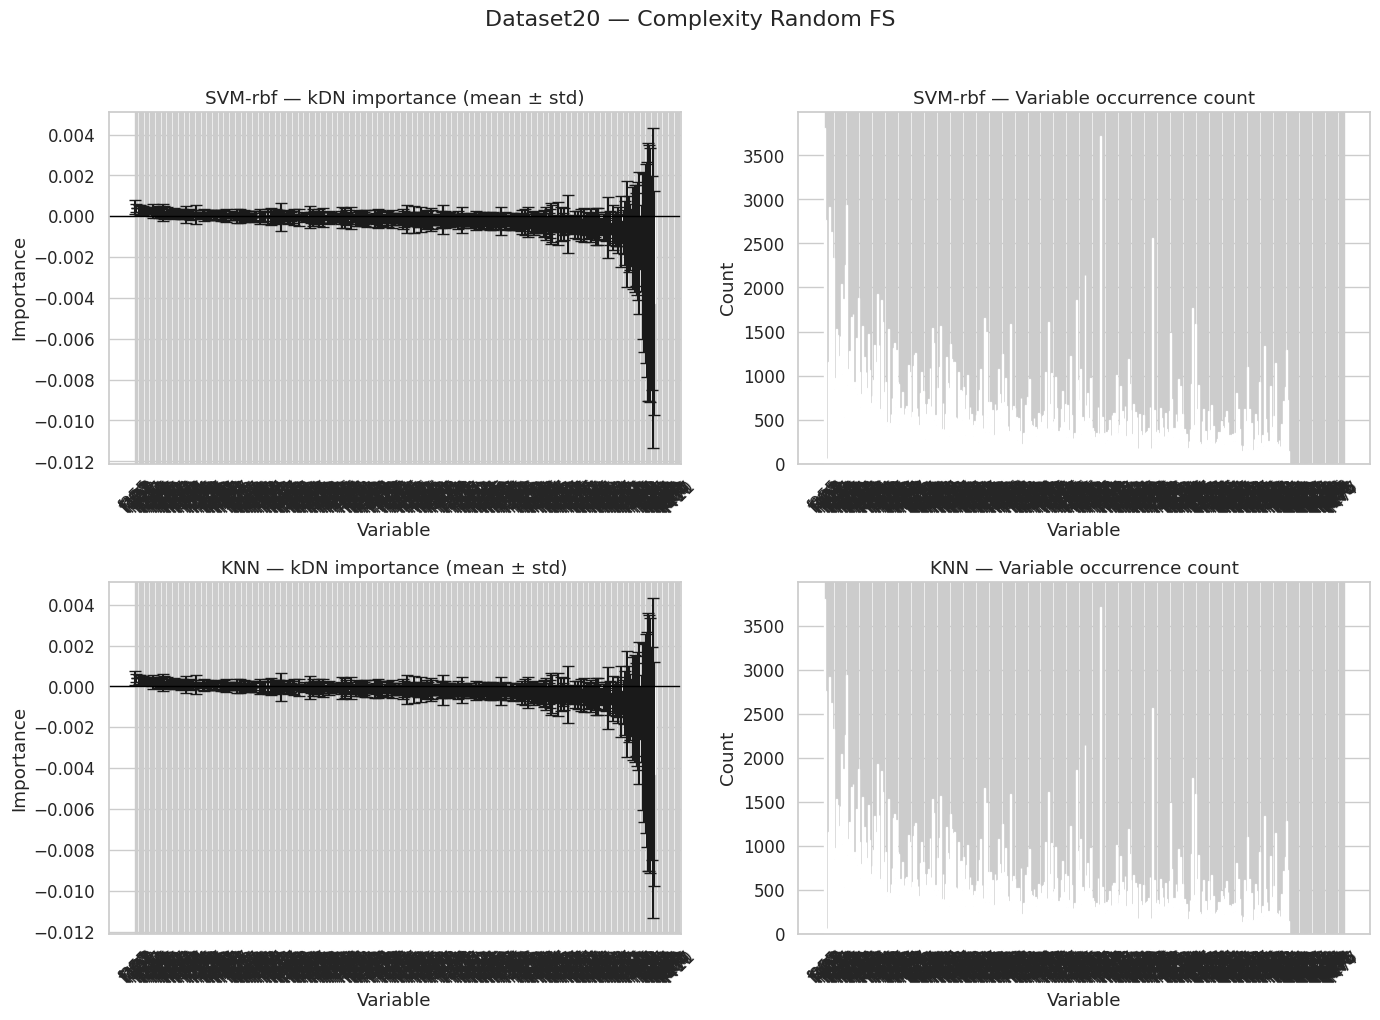

In [9]:
# # Dataset 20
df_random = pd.read_csv("Results_FS_Distributed_CV/ArtificialDataset20_DistributedCVRandom_OutHigh_FeatureImportance_Folds.csv", index_col=0)

plot_complexity_importances_by_model(df_random, dataset_name="Dataset20")

In [16]:
# # Dataset 21
# df_random = pd.read_csv("Results_FS_Distributed_CV/ArtificialDataset21_DistributedCVRandom_OutHigh_FeatureImportance_Folds.csv", index_col=0)
#
# plot_complexity_importances_by_model(df_random, dataset_name="Dataset21")

VER CUÁLES SON SIEMPRE POSITIVAS Y ANALIZAR CÓMO VA LA PERFORMANCE SOLO CON ELLAS

ME QUEDO AQUÍ
## Tabla de comparación SOTA vs distributed (backward)

In [17]:
# Leer todos los comparison.csv de la carpeta
files = glob.glob("Results_ComparisonDistributed_SOTA/*_comparisonTable.csv")

all_tables = []
for f in files:
    df = pd.read_csv(f, index_col=[1])
    all_tables.append(df)

comparison_all = pd.concat(all_tables)
comparison_all.head()

,Dataset,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,...,mean_acc_std,mean_gps_mean,mean_gps_max,mean_gps_std,mean_acc_class_0_mean,mean_acc_class_0_max,mean_acc_class_0_std,mean_acc_class_1_mean,mean_acc_class_1_max,mean_acc_class_1_std
Subset,,,,,,,,,,,,,,,,,,,,,
all,ArtificialDataset11,0.105000,0.139200,0.061444,0.625549,0.336151,0.106733,0.469081,0.992561,0.994698,...,0.090419,0.857646,0.964681,0.093137,0.839063,0.945833,0.102299,0.881389,0.980000,0.126878
informative,ArtificialDataset11,0.057667,0.096600,0.174364,0.549833,0.274323,0.061933,0.442667,0.989020,0.994350,...,0.082885,0.877697,0.985046,0.088807,0.838646,0.980000,0.117334,0.915972,0.989444,0.063723
informative+redundant,ArtificialDataset11,0.066667,0.098067,0.080864,0.655375,0.292417,0.061163,0.439788,0.988041,0.993317,...,0.084417,0.878291,0.983309,0.090084,0.840729,0.978333,0.116382,0.915208,0.987778,0.069146
informative+redundant_nonLinear,ArtificialDataset11,0.092000,0.130200,0.082756,0.556537,0.367372,0.093408,0.449429,0.991863,0.994362,...,0.110298,0.854628,0.979814,0.113850,0.854375,0.972500,0.116122,0.866597,0.986111,0.166378
informative+noise,ArtificialDataset11,0.152333,0.216800,0.174364,0.583981,0.274573,0.181821,0.481774,0.996506,0.996025,...,0.067983,0.850266,0.948097,0.072646,0.800208,0.919167,0.089508,0.898542,0.971667,0.058451


In [18]:
display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset2'].iloc[:,1:].style.background_gradient(cmap="viridis"))

,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,L1,n_features,mean_acc_mean,mean_acc_max,mean_acc_std,mean_gps_mean,mean_gps_max,mean_gps_std,mean_acc_class_0_mean,mean_acc_class_0_max,mean_acc_class_0_std,mean_acc_class_1_mean,mean_acc_class_1_max,mean_acc_class_1_std
Subset,,,,,,,,,,,,,,,,,,,,,,,
all,0.096000,0.130800,0.102014,0.671750,0.247673,0.101082,0.423927,0.976896,0.984222,0.483732,18.000000,0.895750,0.963000,0.051294,0.895554,0.962990,0.051494,0.892750,0.952000,0.047796,0.898750,0.974000,0.057241
informative,0.078000,0.107400,0.088088,0.593333,0.249648,0.067752,0.402904,0.971353,0.983600,0.422721,10.000000,0.903375,0.977000,0.059416,0.903199,0.976996,0.059624,0.900250,0.970000,0.059833,0.906500,0.984000,0.060245
informative+redundant,0.087000,0.115200,0.105041,0.647500,0.264310,0.094810,0.402504,0.971571,0.982000,0.470010,14.000000,0.897125,0.971000,0.059415,0.896924,0.970991,0.059632,0.894250,0.962000,0.060563,0.900000,0.980000,0.060729
informative+redundant_nonLinear,0.069000,0.111200,0.023133,0.650182,0.245998,0.084667,0.404127,0.974451,0.984417,0.428464,12.000000,0.900875,0.971000,0.055743,0.900704,0.970993,0.055905,0.894500,0.964000,0.059663,0.907250,0.978000,0.052611
informative+noise,0.105000,0.137400,0.088088,0.597500,0.245478,0.090355,0.429860,0.979780,0.985583,0.450263,12.000000,0.897625,0.965000,0.053926,0.897434,0.964985,0.054132,0.892500,0.958000,0.052793,0.902750,0.972000,0.056223
informative+rand_extra,0.090000,0.126400,0.137654,0.598923,0.265848,0.096774,0.418381,0.976110,0.983154,0.470098,13.000000,0.893500,0.963000,0.057582,0.893353,0.962983,0.057714,0.889250,0.950000,0.056820,0.897750,0.976000,0.059985
mutual_info_top10,0.114000,0.179200,0.144307,0.399286,0.277373,0.164100,0.411188,0.981062,0.978300,0.141435,10.000000,0.856000,0.909000,0.043504,0.855590,0.908833,0.043626,0.876000,0.936000,0.048838,0.836000,0.890000,0.043134
f_classif_top10,0.131000,0.191400,0.195597,0.574923,0.282936,0.178617,0.422653,0.978922,0.980500,0.508600,10.000000,0.847125,0.898000,0.039873,0.846809,0.897706,0.039891,0.864500,0.932000,0.048494,0.829750,0.872000,0.033627
rf_top10,0.096000,0.128000,0.065991,0.634333,0.258633,0.110783,0.390631,0.961844,0.978300,0.057537,10.000000,0.873500,0.933000,0.051119,0.873251,0.932956,0.051305,0.876750,0.940000,0.054332,0.870250,0.926000,0.051641


In [19]:
display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset3'].iloc[:,1:].style.background_gradient(cmap="viridis"))

,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,L1,n_features,mean_acc_mean,mean_acc_max,mean_acc_std,mean_gps_mean,mean_gps_max,mean_gps_std,mean_acc_class_0_mean,mean_acc_class_0_max,mean_acc_class_0_std,mean_acc_class_1_mean,mean_acc_class_1_max,mean_acc_class_1_std
Subset,,,,,,,,,,,,,,,,,,,,,,,
all,0.050000,0.095000,0.128174,0.649000,0.161818,0.063008,0.458697,0.977972,0.989133,1.132809,45.000000,0.933875,0.985000,0.050456,0.933787,0.984994,0.050570,0.945250,0.994000,0.042988,0.922500,0.976000,0.059327
informative,0.056000,0.076800,0.004889,0.652923,0.140096,0.037496,0.445379,0.968942,0.986720,0.818155,25.000000,0.942500,0.993000,0.046736,0.942435,0.992999,0.046823,0.950000,0.994000,0.039799,0.935000,0.992000,0.054469
informative+redundant,0.043000,0.076600,0.007771,0.662077,0.129405,0.050861,0.445285,0.969741,0.987688,1.033983,32.000000,0.942500,0.992000,0.046944,0.942423,0.991998,0.047047,0.954750,0.992000,0.038202,0.930250,0.992000,0.056167
informative+redundant_nonLinear,0.042000,0.084600,0.065883,0.643846,0.178253,0.049119,0.449176,0.974485,0.988182,0.838673,33.000000,0.937125,0.988000,0.048994,0.937058,0.987997,0.049061,0.943000,0.994000,0.045103,0.931250,0.984000,0.053803
informative+noise,0.070000,0.100400,0.067468,0.653308,0.141118,0.072137,0.459966,0.977409,0.987700,0.815994,30.000000,0.937500,0.987000,0.049659,0.937437,0.986995,0.049756,0.943250,0.992000,0.045292,0.931750,0.982000,0.054368
informative+rand_extra,0.049000,0.081200,0.087372,0.630462,0.149967,0.051504,0.449929,0.973543,0.987464,0.835489,28.000000,0.938875,0.992000,0.048117,0.938790,0.991999,0.048234,0.947250,0.994000,0.041334,0.930500,0.990000,0.056364
mutual_info_top25,0.071000,0.105000,0.086882,0.628385,0.176572,0.088723,0.443005,0.969790,0.986640,1.020301,25.000000,0.929375,0.972000,0.044055,0.928990,0.971977,0.044708,0.951000,0.988000,0.035440,0.907750,0.958000,0.073098
f_classif_top25,0.101000,0.134400,0.104078,0.607385,0.186626,0.097306,0.447587,0.975521,0.986480,1.178811,25.000000,0.913000,0.956000,0.042068,0.912460,0.955976,0.042957,0.938500,0.970000,0.038851,0.887500,0.946000,0.073085
rf_top25,0.057000,0.093200,0.088500,0.640308,0.148828,0.078495,0.436126,0.967896,0.985840,0.993947,25.000000,0.936625,0.981000,0.041165,0.936536,0.980992,0.041234,0.947250,0.988000,0.038825,0.926000,0.974000,0.045969


In [20]:
display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset7'].iloc[:,1:].style.background_gradient(cmap="viridis"))

,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,L1,n_features,mean_acc_mean,mean_acc_max,mean_acc_std,mean_gps_mean,mean_gps_max,mean_gps_std,mean_acc_class_0_mean,mean_acc_class_0_max,mean_acc_class_0_std,mean_acc_class_1_mean,mean_acc_class_1_max,mean_acc_class_1_std
Subset,,,,,,,,,,,,,,,,,,,,,,,
all,0.027000,0.054400,0.052702,0.690917,0.148801,0.037635,0.445946,0.958892,0.986120,1.312835,50.000000,0.965500,0.994000,0.033848,0.965481,0.994000,0.033878,0.969750,0.996000,0.037863,0.961250,0.992000,0.030705
informative,0.008000,0.027200,0.047885,0.740700,0.067308,0.018279,0.411489,0.931018,0.981650,1.009091,20.000000,0.973875,0.999000,0.031466,0.973863,0.999000,0.031488,0.976500,1.000000,0.033205,0.971250,0.998000,0.030443
informative+redundant,0.014000,0.033000,0.011744,0.701182,0.097685,0.020969,0.413391,0.940088,0.983067,1.082760,30.000000,0.970375,1.000000,0.036485,0.970357,1.000000,0.036514,0.970750,1.000000,0.041182,0.970000,1.000000,0.032320
informative+redundant_nonLinear,0.015000,0.032000,0.049770,0.747700,0.137310,0.018700,0.416961,0.940200,0.983367,1.199497,30.000000,0.969500,0.996000,0.032413,0.969478,0.996000,0.032452,0.974250,0.998000,0.033881,0.964750,0.996000,0.031927
informative+noise,0.049000,0.062200,0.051221,0.658154,0.069280,0.048519,0.453899,0.968383,0.985967,1.013354,30.000000,0.971500,0.997000,0.029809,0.971481,0.997000,0.029843,0.974250,1.000000,0.031231,0.968750,0.994000,0.028843
informative+rand_extra,0.008000,0.031200,0.042871,0.714091,0.072162,0.020702,0.419714,0.941798,0.982391,1.141526,23.000000,0.973500,0.999000,0.030905,0.973485,0.999000,0.030935,0.977500,1.000000,0.030005,0.969500,0.998000,0.032262
mutual_info_top20,0.022000,0.043200,0.043262,0.753600,0.144102,0.038703,0.393945,0.928998,0.976150,0.917458,20.000000,0.960375,0.989000,0.040352,0.960251,0.988998,0.040568,0.976750,0.996000,0.031874,0.944000,0.984000,0.059059
f_classif_top20,0.024000,0.046400,0.003902,0.725600,0.093106,0.039335,0.396194,0.933647,0.976600,0.914243,20.000000,0.966875,0.990000,0.032982,0.966856,0.989999,0.033013,0.972500,0.994000,0.035193,0.961250,0.988000,0.032052
rf_top20,0.023000,0.035000,0.047594,0.746100,0.129881,0.033210,0.391093,0.930719,0.976550,1.148835,20.000000,0.963750,0.995000,0.039741,0.963636,0.994999,0.039935,0.978000,0.998000,0.035165,0.949500,0.992000,0.056828


In [21]:
display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset8'].iloc[:,1:].style.background_gradient(cmap="viridis"))

,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,L1,n_features,mean_acc_mean,mean_acc_max,mean_acc_std,mean_gps_mean,mean_gps_max,mean_gps_std,mean_acc_class_0_mean,mean_acc_class_0_max,mean_acc_class_0_std,mean_acc_class_1_mean,mean_acc_class_1_max,mean_acc_class_1_std
Subset,,,,,,,,,,,,,,,,,,,,,,,
all,0.129000,0.184000,0.195545,0.660833,0.290143,0.124608,0.478911,0.987986,0.991871,0.539881,85.000000,0.871000,0.962000,0.070488,0.870786,0.961934,0.070601,0.854750,0.942000,0.066004,0.887250,0.982000,0.077776
informative,0.053000,0.128000,0.206128,0.616000,0.224660,0.091075,0.468715,0.983293,0.991350,0.788417,40.000000,0.885875,0.985000,0.085678,0.885610,0.984993,0.086006,0.871000,0.976000,0.083173,0.900750,0.994000,0.089895
informative+redundant,0.068000,0.152000,0.160299,0.635000,0.259886,0.101738,0.469315,0.984918,0.991400,0.218165,55.000000,0.882000,0.981000,0.074187,0.881822,0.980992,0.074324,0.867250,0.974000,0.068594,0.896750,0.988000,0.082010
informative+redundant_nonLinear,0.094000,0.142000,0.193916,0.657929,0.282043,0.095126,0.470209,0.984890,0.991455,0.665166,55.000000,0.888500,0.983000,0.073807,0.888335,0.982991,0.073918,0.878500,0.972000,0.068692,0.898500,0.994000,0.079948
informative+noise,0.120000,0.180800,0.206128,0.616214,0.225714,0.118507,0.480132,0.989130,0.992000,0.798303,55.000000,0.875250,0.969000,0.076701,0.874998,0.968981,0.076835,0.861250,0.954000,0.075585,0.889250,0.984000,0.080916
informative+rand_extra,0.071000,0.131200,0.206128,0.615857,0.251437,0.086931,0.469220,0.983671,0.991442,0.804831,43.000000,0.880125,0.984000,0.088850,0.878482,0.983992,0.091081,0.847750,0.974000,0.124269,0.912500,0.994000,0.086947
mutual_info_top40,0.171000,0.224400,0.146686,0.717000,0.285754,0.189818,0.472984,0.987705,0.990525,0.103143,40.000000,0.854625,0.915000,0.054356,0.854335,0.914815,0.054488,0.834500,0.892000,0.049451,0.874750,0.948000,0.065639
f_classif_top40,0.166000,0.218000,0.181005,0.517067,0.295342,0.191840,0.472983,0.987842,0.991000,0.996513,40.000000,0.847375,0.918000,0.054560,0.846775,0.917891,0.055091,0.835000,0.892000,0.040469,0.859750,0.944000,0.087632
rf_top40,0.121000,0.182400,0.084212,0.599923,0.290086,0.150197,0.467276,0.984910,0.990300,0.975738,40.000000,0.867875,0.941000,0.060563,0.867551,0.940902,0.060711,0.843250,0.920000,0.055156,0.892500,0.972000,0.069765


In [22]:
display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset10'].iloc[:,1:].style.background_gradient(cmap="viridis"))

,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,L1,n_features,mean_acc_mean,mean_acc_max,mean_acc_std,mean_gps_mean,mean_gps_max,mean_gps_std,mean_acc_class_0_mean,mean_acc_class_0_max,mean_acc_class_0_std,mean_acc_class_1_mean,mean_acc_class_1_max,mean_acc_class_1_std
Subset,,,,,,,,,,,,,,,,,,,,,,,
all,0.144000,0.160100,0.149454,0.550658,0.317714,0.160810,0.455342,0.982259,0.991197,0.906692,61.000000,0.870875,0.912000,0.041100,0.832287,0.886961,0.046553,0.705625,0.778333,0.041211,0.941696,0.990714,0.056295
informative,0.079500,0.125100,0.159981,0.575167,0.280286,0.119875,0.364366,0.970477,0.988167,0.665170,6.000000,0.885375,0.926500,0.039192,0.846762,0.903675,0.057514,0.712708,0.800000,0.091880,0.959375,0.993571,0.033902
informative+redundant,0.090500,0.139100,0.144569,0.527972,0.321964,0.118967,0.389214,0.976058,0.987731,1.027539,26.000000,0.879188,0.919500,0.049207,0.844673,0.898795,0.055229,0.728542,0.813333,0.058448,0.943750,0.990000,0.067683
informative+redundant_nonLinear,0.108000,0.140100,0.118037,0.631938,0.315713,0.122586,0.392545,0.977392,0.989571,0.434663,21.000000,0.877375,0.912500,0.038657,0.838772,0.881699,0.051531,0.710833,0.786667,0.062259,0.948750,0.993571,0.039013
informative+noise,0.229000,0.286000,0.159981,0.622687,0.280023,0.264936,0.483063,0.996408,0.994577,0.670839,26.000000,0.852750,0.905000,0.042451,0.793995,0.878586,0.069522,0.627500,0.771667,0.102821,0.949286,0.989286,0.040073
informative+rand_extra,0.088500,0.127400,0.165385,0.517437,0.335485,0.116308,0.368267,0.973692,0.987722,0.666963,9.000000,0.876563,0.920500,0.050398,0.824050,0.894107,0.101544,0.678333,0.798333,0.153282,0.961518,0.994286,0.029046
mutual_info_top6,0.147000,0.224400,0.213949,0.389937,0.300827,0.221017,0.409616,0.990258,0.988833,0.653762,6.000000,0.830750,0.858000,0.025860,0.775208,0.815461,0.029647,0.637708,0.705000,0.047400,0.913482,0.955000,0.040150
f_classif_top6,0.147000,0.212400,0.223497,0.555088,0.300808,0.215575,0.399183,0.987780,0.986250,1.359141,6.000000,0.811750,0.847500,0.030554,0.749237,0.790537,0.043338,0.617708,0.688333,0.071741,0.894911,0.947857,0.042113
rf_top6,0.111000,0.151900,0.179426,0.428636,0.255337,0.144058,0.352852,0.974198,0.991500,0.634135,6.000000,0.873500,0.894000,0.025348,0.834459,0.863071,0.028476,0.706875,0.755000,0.046346,0.944911,0.987857,0.041528


In [23]:
display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset11'].iloc[:,1:].style.background_gradient(cmap="viridis"))

,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,L1,n_features,mean_acc_mean,mean_acc_max,mean_acc_std,mean_gps_mean,mean_gps_max,mean_gps_std,mean_acc_class_0_mean,mean_acc_class_0_max,mean_acc_class_0_std,mean_acc_class_1_mean,mean_acc_class_1_max,mean_acc_class_1_std
Subset,,,,,,,,,,,,,,,,,,,,,,,
all,0.105000,0.139200,0.061444,0.625549,0.336151,0.106733,0.469081,0.992561,0.994698,0.504040,75.000000,0.864458,0.966333,0.090419,0.857646,0.964681,0.093137,0.839063,0.945833,0.102299,0.881389,0.980000,0.126878
informative,0.057667,0.096600,0.174364,0.549833,0.274323,0.061933,0.442667,0.989020,0.994350,0.571514,20.000000,0.885042,0.985667,0.082885,0.877697,0.985046,0.088807,0.838646,0.980000,0.117334,0.915972,0.989444,0.063723
informative+redundant,0.066667,0.098067,0.080864,0.655375,0.292417,0.061163,0.439788,0.988041,0.993317,0.540162,40.000000,0.885417,0.984000,0.084417,0.878291,0.983309,0.090084,0.840729,0.978333,0.116382,0.915208,0.987778,0.069146
informative+redundant_nonLinear,0.092000,0.130200,0.082756,0.556537,0.367372,0.093408,0.449429,0.991863,0.994362,0.505634,35.000000,0.861708,0.980667,0.110298,0.854628,0.979814,0.113850,0.854375,0.972500,0.116122,0.866597,0.986111,0.166378
informative+noise,0.152333,0.216800,0.174364,0.583981,0.274573,0.181821,0.481774,0.996506,0.996025,0.574145,40.000000,0.859208,0.950667,0.067983,0.850266,0.948097,0.072646,0.800208,0.919167,0.089508,0.898542,0.971667,0.058451
informative+rand_extra,0.082667,0.094533,0.176317,0.523877,0.309336,0.066025,0.441935,0.988337,0.994043,0.565375,23.000000,0.879250,0.984000,0.088040,0.872433,0.983306,0.092899,0.845104,0.977500,0.113887,0.902014,0.988333,0.088955
mutual_info_top20,0.139333,0.194533,0.110375,0.529877,0.329754,0.169764,0.450809,0.993806,0.990667,0.342375,20.000000,0.828375,0.922333,0.073379,0.819450,0.918068,0.074932,0.800833,0.925000,0.091437,0.846736,0.946111,0.120936
f_classif_top20,0.103333,0.178133,0.096553,0.635583,0.333745,0.154507,0.449857,0.992941,0.991550,0.628668,20.000000,0.844458,0.950333,0.076429,0.835004,0.947700,0.081178,0.788021,0.916667,0.093913,0.882083,0.972778,0.072752
rf_top20,0.109667,0.142533,0.187803,0.564510,0.276387,0.117806,0.440804,0.989752,0.990933,0.349706,20.000000,0.863708,0.952667,0.069253,0.853775,0.950050,0.075433,0.792813,0.915833,0.098492,0.910972,0.977222,0.051285


In [24]:
display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset12'].iloc[:,1:].style.background_gradient(cmap="viridis"))

,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,L1,n_features,mean_acc_mean,mean_acc_max,mean_acc_std,mean_gps_mean,mean_gps_max,mean_gps_std,mean_acc_class_0_mean,mean_acc_class_0_max,mean_acc_class_0_std,mean_acc_class_1_mean,mean_acc_class_1_max,mean_acc_class_1_std
Subset,,,,,,,,,,,,,,,,,,,,,,,
all,0.182333,0.262467,0.292444,0.534960,0.392270,0.246505,0.486406,0.997126,0.997551,0.781137,115.000000,0.798417,0.872000,0.064805,0.786513,0.866020,0.069523,0.711129,0.806686,0.074738,0.861372,0.919084,0.063950
informative,0.143000,0.234333,0.278586,0.535712,0.346237,0.213641,0.474360,0.996675,0.997480,0.482905,25.000000,0.815792,0.886333,0.060785,0.806226,0.881656,0.063539,0.737262,0.834533,0.067979,0.872400,0.923668,0.061856
informative+redundant,0.145667,0.244000,0.298350,0.422258,0.361075,0.223381,0.475779,0.996955,0.997461,0.563607,55.000000,0.814875,0.884000,0.061854,0.805674,0.879135,0.064005,0.738863,0.830552,0.063095,0.869672,0.922522,0.066122
informative+redundant_nonLinear,0.135000,0.249533,0.336279,0.533470,0.401650,0.239003,0.477403,0.996886,0.997358,0.552386,55.000000,0.801167,0.878667,0.068905,0.787177,0.873335,0.078844,0.709559,0.820203,0.097317,0.867258,0.920798,0.061725
informative+noise,0.203667,0.309533,0.322540,0.525551,0.349617,0.292228,0.491331,0.998033,0.997770,0.498972,55.000000,0.797083,0.866000,0.057765,0.785800,0.859003,0.059797,0.707145,0.787606,0.054793,0.861931,0.922525,0.063570
informative+rand_extra,0.147667,0.235800,0.276547,0.573550,0.352342,0.216239,0.476667,0.996758,0.997536,0.467870,28.000000,0.815167,0.884667,0.060712,0.805536,0.879818,0.063271,0.735375,0.830552,0.065220,0.872686,0.923665,0.063364
mutual_info_top25,0.189000,0.301533,0.272266,0.623907,0.387758,0.298432,0.476449,0.997531,0.997080,0.690632,25.000000,0.774208,0.836667,0.049619,0.759195,0.827648,0.053980,0.671874,0.750210,0.065015,0.848020,0.898989,0.052659
f_classif_top25,0.221667,0.303733,0.276931,0.534889,0.380682,0.284980,0.472131,0.997390,0.996773,0.452094,25.000000,0.767583,0.828000,0.046664,0.754479,0.817127,0.047543,0.675911,0.728711,0.043631,0.833658,0.902440,0.059226
rf_top25,0.180333,0.299667,0.282076,0.566650,0.392885,0.293268,0.471664,0.997337,0.996947,0.576730,25.000000,0.769750,0.828000,0.049101,0.752969,0.817312,0.056500,0.660927,0.735860,0.079041,0.848241,0.900141,0.048407


In [25]:
display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset14'].iloc[:,1:].style.background_gradient(cmap="viridis"))

,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,L1,n_features,mean_acc_mean,mean_acc_max,mean_acc_std,mean_gps_mean,mean_gps_max,mean_gps_std,mean_acc_class_0_mean,mean_acc_class_0_max,mean_acc_class_0_std,mean_acc_class_1_mean,mean_acc_class_1_max,mean_acc_class_1_std
Subset,,,,,,,,,,,,,,,,,,,,,,,
all,0.207667,0.305267,0.366466,0.541136,0.447033,0.275657,0.490385,0.998005,0.997445,0.166529,140.000000,0.698375,0.837333,0.141782,0.605853,0.798045,0.179733,0.540381,0.972946,0.196786,0.781631,0.955229,0.297376
informative,0.162333,0.273400,0.426914,0.579206,0.415963,0.246886,0.481518,0.997686,0.997400,0.496093,30.000000,0.757333,0.874333,0.077779,0.676895,0.849969,0.113663,0.500250,0.722657,0.150068,0.892755,0.955232,0.077376
informative+redundant,0.180000,0.284400,0.409525,0.632070,0.416642,0.255571,0.481636,0.997819,0.997244,0.244660,60.000000,0.757458,0.864667,0.074022,0.686829,0.837542,0.103337,0.526104,0.704285,0.134960,0.879337,0.954719,0.086618
informative+redundant_nonLinear,0.196000,0.292933,0.369773,0.576300,0.448560,0.276069,0.484134,0.997886,0.997352,0.236608,70.000000,0.712667,0.859667,0.150086,0.622946,0.829859,0.198319,0.567046,0.975850,0.205502,0.789376,0.950632,0.301480
informative+noise,0.261333,0.361267,0.426914,0.589530,0.413451,0.341170,0.493940,0.998556,0.997671,0.500557,70.000000,0.716542,0.795667,0.053094,0.606642,0.725489,0.071313,0.403069,0.529453,0.088071,0.881691,0.970999,0.079529
informative+rand_extra,0.168333,0.278267,0.426914,0.644053,0.428349,0.242553,0.482547,0.997723,0.997465,0.484717,33.000000,0.729458,0.872000,0.121188,0.657374,0.846322,0.133511,0.559568,0.918848,0.200403,0.818964,0.956744,0.235766
mutual_info_top30,0.270667,0.371200,0.410450,0.525931,0.431596,0.359996,0.487564,0.998555,0.997100,0.260822,30.000000,0.670625,0.743667,0.072132,0.501558,0.651827,0.209635,0.391535,0.797928,0.224327,0.817612,0.998982,0.197074
f_classif_top30,0.239667,0.345667,0.391809,0.550267,0.417560,0.332297,0.484205,0.998356,0.997078,0.595886,30.000000,0.713917,0.798333,0.054886,0.611361,0.740703,0.087880,0.430616,0.550709,0.112749,0.863183,0.951163,0.088566
rf_top30,0.228667,0.330000,0.337751,0.526921,0.435921,0.304406,0.482769,0.998251,0.997000,0.813853,30.000000,0.691917,0.808333,0.122761,0.593516,0.759028,0.144375,0.512467,0.942896,0.212295,0.786450,0.953206,0.272493


In [26]:
# display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset16'].iloc[:,1:].style.background_gradient(cmap="viridis"))

In [27]:
# display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset17'].iloc[:,1:].style.background_gradient(cmap="viridis"))

In [28]:
# display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset18'].iloc[:,1:].style.background_gradient(cmap="viridis"))

In [29]:
# display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset19'].iloc[:,1:].style.background_gradient(cmap="viridis"))

In [30]:
# display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset20'].iloc[:,1:].style.background_gradient(cmap="viridis"))

In [31]:
# display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset21'].iloc[:,1:].style.background_gradient(cmap="viridis"))

## Estudio variables con "importancia" negativa

In [32]:
dataset_name = 'ArtificialDataset2'
X, y, dict_info_feature = generate_synthetic_dataset(n_samples=1000,n_informative=10,n_noise=2,
                                         n_redundant_linear=4,n_redundant_nonlinear=2,
                                    flip_y=0, class_sep = 0.6, n_clusters_per_class=1 , weights=[0.5],
                                                     random_state=0,noise_std=0.01)

csv_path = "Results_FS_Distributed/ArtificialDataset2_ComplexityRandomDistributed.csv"
summary_neg = analyze_negative_importances(csv_path, dict_info_feature)
summary_neg

,measure,n_negatives,pct_informative,pct_noise,pct_redundant_linear,pct_redundant_nonlinear
0,Hostility_importances_norm,0,0,0.0,0,0
1,N1_importances_norm,2,0,100.0,0,0
2,kDN_importances_norm,2,0,100.0,0,0


In [33]:
### Dataset 3
dataset_name = 'ArtificialDataset3'
X, y, dict_info_feature = generate_synthetic_dataset(n_samples=1000,n_informative=25,n_noise=5,
                                         n_redundant_linear=7,n_redundant_nonlinear=8,
                                         flip_y=0, class_sep=1, n_clusters_per_class=1, weights=[0.5],
                                                     random_state=0,noise_std=0.05)

csv_path = "Results_FS_Distributed/ArtificialDataset3_ComplexityRandomDistributed.csv"
summary_neg = analyze_negative_importances(csv_path, dict_info_feature)
summary_neg

,measure,n_negatives,pct_informative,pct_noise,pct_redundant_linear,pct_redundant_nonlinear
0,Hostility_importances_norm,6,33.33,50.0,0,16.67
1,N1_importances_norm,3,0.00,100.0,0,0.00
2,kDN_importances_norm,4,0.00,100.0,0,0.00


In [34]:
#### Dataset 7
dataset_name = 'ArtificialDataset7'
X, y, dict_info_feature = generate_synthetic_dataset(n_samples=1000,n_informative=20,n_noise=10,
                                         n_redundant_linear=10,n_redundant_nonlinear=10,
                                        flip_y=0, class_sep=1, n_clusters_per_class=1, weights=[0.5],
                                                     random_state=589,noise_std=0.05)

csv_path = "Results_FS_Distributed/ArtificialDataset7_ComplexityRandomDistributed.csv"
summary_neg = analyze_negative_importances(csv_path, dict_info_feature)
summary_neg

,measure,n_negatives,pct_informative,pct_noise,pct_redundant_linear,pct_redundant_nonlinear
0,Hostility_importances_norm,10,10.0,70.0,0,20.0
1,N1_importances_norm,9,0.0,100.0,0,0.0
2,kDN_importances_norm,10,0.0,100.0,0,0.0


In [35]:
#### Dataset 8
dataset_name = 'ArtificialDataset8'
X, y, dict_info_feature = generate_synthetic_dataset(n_samples=1000,n_informative=40,n_noise=15,
                                         n_redundant_linear=15,n_redundant_nonlinear=15,
                                        flip_y=0, class_sep=1, n_clusters_per_class=1, weights=[0.5],
                                                     random_state=86785,noise_std=0.1)

csv_path = "Results_FS_Distributed/ArtificialDataset8_ComplexityRandomDistributed.csv"
summary_neg = analyze_negative_importances(csv_path, dict_info_feature)
summary_neg

,measure,n_negatives,pct_informative,pct_noise,pct_redundant_linear,pct_redundant_nonlinear
0,Hostility_importances_norm,17,23.53,58.82,5.88,11.76
1,N1_importances_norm,16,18.75,68.75,0.00,12.50
2,kDN_importances_norm,16,12.50,75.00,0.00,12.50


In [36]:
#### Dataset 10
dataset_name = 'ArtificialDataset10'
X, y, dict_info_feature = generate_synthetic_dataset(n_samples=2000,n_informative=6,n_noise=20,
                                         n_redundant_linear=20,n_redundant_nonlinear=15,
                                        flip_y=0, class_sep=0.8, n_clusters_per_class=2, weights=[0.3],
                                                     random_state=959,noise_std=0.3)

csv_path = "Results_FS_Distributed/ArtificialDataset10_ComplexityRandomDistributed.csv"
summary_neg = analyze_negative_importances(csv_path, dict_info_feature)
summary_neg

,measure,n_negatives,pct_informative,pct_noise,pct_redundant_linear,pct_redundant_nonlinear
0,Hostility_importances_norm,20,0,100.0,0,0
1,N1_importances_norm,19,0,100.0,0,0
2,kDN_importances_norm,20,0,100.0,0,0


In [37]:
#### Dataset 11
dataset_name = 'ArtificialDataset11'
X, y, dict_info_feature = generate_synthetic_dataset(n_samples=3000,n_informative=20,n_noise=20,
                                         n_redundant_linear=20,n_redundant_nonlinear=15,
                                        flip_y=0, class_sep=0.6, n_clusters_per_class=1, weights=[0.4],
                                                     random_state=959,noise_std=0.1)

csv_path = "Results_FS_Distributed/ArtificialDataset11_ComplexityRandomDistributed.csv"
summary_neg = analyze_negative_importances(csv_path, dict_info_feature)
summary_neg

,measure,n_negatives,pct_informative,pct_noise,pct_redundant_linear,pct_redundant_nonlinear
0,Hostility_importances_norm,18,0,94.44,0,5.56
1,N1_importances_norm,20,0,100.00,0,0.00
2,kDN_importances_norm,19,0,100.00,0,0.00


In [38]:
#### Dataset 12
dataset_name = 'ArtificialDataset12'
X, y, dict_info_feature = generate_synthetic_dataset(n_samples=3000,n_informative=25,n_noise=30,
                                         n_redundant_linear=30,n_redundant_nonlinear=30,
                                        flip_y=0.2, class_sep=0.9, n_clusters_per_class=1, weights=[0.4],
                                                     random_state=987,noise_std=0.5)

csv_path = "Results_FS_Distributed/ArtificialDataset12_ComplexityRandomDistributed.csv"
summary_neg = analyze_negative_importances(csv_path, dict_info_feature)
summary_neg

,measure,n_negatives,pct_informative,pct_noise,pct_redundant_linear,pct_redundant_nonlinear
0,Hostility_importances_norm,31,12.9,70.97,3.23,12.90
1,N1_importances_norm,19,0.0,94.74,0.00,5.26
2,kDN_importances_norm,29,0.0,89.66,0.00,10.34


In [39]:
# #### Dataset 14
dataset_name = 'ArtificialDataset14'
X, y, dict_info_feature = generate_synthetic_dataset(n_samples=3000,n_informative=30,n_noise=40,
                                         n_redundant_linear=30,n_redundant_nonlinear=40,
                                        flip_y=0.2, class_sep=0.6, n_clusters_per_class=2, weights=[0.3],
                                                     random_state=95,noise_std=0.5)

csv_path = "Results_FS_Distributed/ArtificialDataset14_ComplexityRandomDistributed.csv"
summary_neg = analyze_negative_importances(csv_path, dict_info_feature)
summary_neg

,measure,n_negatives,pct_informative,pct_noise,pct_redundant_linear,pct_redundant_nonlinear
0,Hostility_importances_norm,35,11.43,71.43,8.57,8.57
1,N1_importances_norm,32,12.50,68.75,6.25,12.50
2,kDN_importances_norm,38,5.26,73.68,0.00,21.05


In [40]:
# #### Dataset 16
# dataset_name = 'ArtificialDataset16'
# X, y, dict_info_feature = generate_synthetic_dataset(n_samples=1000,n_informative=50,n_noise=40,
#                                          n_redundant_linear=30,n_redundant_nonlinear=40,
#                                         flip_y=0.3, class_sep=0.4, n_clusters_per_class=1, weights=[0.2],
#                                                      random_state=756,noise_std=0.5)

In [41]:
# #### Dataset 17
# dataset_name = 'ArtificialDataset17'
# X, y, dict_info_feature = generate_synthetic_dataset(n_samples=5000,n_informative=70,n_noise=40,
#                                          n_redundant_linear=40,n_redundant_nonlinear=40,
#                                         flip_y=0.3, class_sep=0.6, n_clusters_per_class=2, weights=[0.2],
#                                                      random_state=756,noise_std=0.5)

In [42]:
# #### Dataset 18
# dataset_name = 'ArtificialDataset18'
# X, y, dict_info_feature = generate_synthetic_dataset(n_samples=500,n_informative=70,n_noise=40,
#                                          n_redundant_linear=40,n_redundant_nonlinear=40,
#                                         flip_y=0.4, class_sep=0.8, n_clusters_per_class=2, weights=[0.2],
#                                                      random_state=9462,noise_std=0.5)

In [43]:
# #### Dataset 19
# dataset_name = 'ArtificialDataset19'
# X, y, dict_info_feature = generate_synthetic_dataset(n_samples=500,n_informative=150,n_noise=50,
#                                          n_redundant_linear=50,n_redundant_nonlinear=50,
#                                         flip_y=0.1, class_sep=0.6, n_clusters_per_class=1, weights=[0.3],
#                                                      random_state=655,noise_std=0.5)

In [44]:
# #### Dataset 20
# dataset_name = 'ArtificialDataset20'
# X, y, dict_info_feature = generate_synthetic_dataset(n_samples=500,n_informative=300,n_noise=60,
#                                          n_redundant_linear=60,n_redundant_nonlinear=60,
#                                         flip_y=0.1, class_sep=0.6, n_clusters_per_class=1, weights=[0.3],
#                                                      random_state=4556,noise_std=0.5)

In [45]:
# #### Dataset 21
# dataset_name = 'ArtificialDataset21'
# X, y, dict_info_feature = generate_synthetic_dataset(n_samples=1000,n_informative=300,n_noise=100,
#                                          n_redundant_linear=100,n_redundant_nonlinear=100,
#                                         flip_y=0.1, class_sep=0.7, n_clusters_per_class=2, weights=[0.4],
#                                                      random_state=996,noise_std=0.5)

## Comparación resultados ejecutados para Distributed y para SOTA con CV

¡OJO! Los resultados de los subsets artificiales tipo informative, informative+redundant aun no están ejecutados con CV

In [3]:
df_results = pd.read_csv('Results_ComparisonDistributed_SOTA/AllArtificialDatasets_ComparisonTable_CV.csv')

In [8]:
print('ArficialDataset2')
display(df_results[df_results.dataset == 'ArtificialDataset2'].iloc[:,1:].style.background_gradient(cmap="viridis"))

ArficialDataset2


,method,model,acc_train_mean,acc_train_std,acc_test_mean,acc_test_std,gps_train_mean,gps_train_std,gps_test_mean,gps_test_std,Hostility_mean,Hostility_std,N1_mean,N1_std,kDN_mean,kDN_std,n_features,type,filter_corr
66,informative+rand_extra,mean_model,nan,nan,0.893500,0.000000,nan,nan,0.893353,0.000000,0.090000,nan,0.096774,nan,0.126400,nan,13.000000,Custom,True
67,informative+noise,mean_model,nan,nan,0.897625,0.000000,nan,nan,0.897434,0.000000,0.105000,nan,0.090355,nan,0.137400,nan,12.000000,Custom,True
68,informative+redundant_nonLinear,mean_model,nan,nan,0.900875,0.000000,nan,nan,0.900704,0.000000,0.069000,nan,0.084667,nan,0.111200,nan,12.000000,Custom,True
69,informative+redundant,mean_model,nan,nan,0.897125,0.000000,nan,nan,0.896924,0.000000,0.087000,nan,0.094810,nan,0.115200,nan,14.000000,Custom,True
70,informative,mean_model,nan,nan,0.903375,0.000000,nan,nan,0.903199,0.000000,0.078000,nan,0.067752,nan,0.107400,nan,10.000000,Custom,True
71,N1_importances_norm,SVM-rbf,0.964000,0.005823,0.934000,0.015572,0.963994,0.005825,0.933961,0.015564,0.119250,0.030588,0.121239,0.018631,0.159750,0.027904,nan,Distributed,True
72,Hostility_importances_norm,SVM-rbf,0.960750,0.009787,0.929000,0.019494,0.960737,0.009799,0.928842,0.019753,0.105750,0.025212,0.129367,0.024234,0.158750,0.026948,nan,Distributed,True
73,kDN_importances_norm,KNN,0.954750,0.009858,0.929000,0.020433,0.954745,0.009865,0.928957,0.020439,0.094500,0.022580,0.114627,0.018998,0.145800,0.023329,nan,Distributed,True
74,N1_importances_norm,KNN,0.946500,0.017840,0.921000,0.037316,0.946494,0.017845,0.920939,0.037355,0.119250,0.030588,0.121239,0.018631,0.159750,0.027904,nan,Distributed,True
75,Hostility_importances_norm,KNN,0.951000,0.009618,0.900000,0.015000,0.950984,0.009630,0.899856,0.015077,0.105750,0.025212,0.129367,0.024234,0.158750,0.026948,nan,Distributed,True


In [9]:
print('ArficialDataset7')
display(df_results[df_results.dataset == 'ArtificialDataset7'].iloc[:,1:].style.background_gradient(cmap="viridis"))

ArficialDataset7


,method,model,acc_train_mean,acc_train_std,acc_test_mean,acc_test_std,gps_train_mean,gps_train_std,gps_test_mean,gps_test_std,Hostility_mean,Hostility_std,N1_mean,N1_std,kDN_mean,kDN_std,n_features,type,filter_corr
132,Hostility_importances_norm,KNN,0.991000,0.005956,0.980000,0.015411,0.990999,0.005956,0.979998,0.015413,0.032000,0.010023,0.040246,0.011434,0.057800,0.013919,nan,Distributed,True
133,all,mean_model,nan,nan,0.965500,0.000000,nan,nan,0.965481,0.000000,0.027000,nan,0.037635,nan,0.054400,nan,50.000000,Custom,True
134,informative,mean_model,nan,nan,0.973875,0.000000,nan,nan,0.973863,0.000000,0.008000,nan,0.018279,nan,0.027200,nan,20.000000,Custom,True
135,informative+redundant,mean_model,nan,nan,0.970375,0.000000,nan,nan,0.970357,0.000000,0.014000,nan,0.020969,nan,0.033000,nan,30.000000,Custom,True
136,informative+redundant_nonLinear,mean_model,nan,nan,0.969500,0.000000,nan,nan,0.969478,0.000000,0.015000,nan,0.018700,nan,0.032000,nan,30.000000,Custom,True
137,N1_importances_norm,KNN,0.995000,0.001531,0.990000,0.006124,0.995000,0.001531,0.989998,0.006125,0.020750,0.008909,0.029413,0.007719,0.043000,0.014006,nan,Distributed,True
138,rf,SVM-rbf,0.999250,0.001118,0.995000,0.003536,0.999250,0.001118,0.995000,0.003536,0.019500,0.005047,0.022324,0.002679,0.035650,0.002043,20.000000,SOTA,True
139,Hostility_importances_norm,SVM-rbf,0.998000,0.001677,0.994000,0.006519,0.998000,0.001677,0.994000,0.006519,0.032000,0.010023,0.040246,0.011434,0.057800,0.013919,nan,Distributed,True
140,f_classif,KNN,0.992500,0.002500,0.984000,0.008216,0.992500,0.002500,0.983997,0.008218,0.027750,0.013416,0.031693,0.008318,0.046850,0.008856,20.000000,SOTA,True
141,N1_importances_norm,SVM-rbf,0.999500,0.000685,0.995000,0.006124,0.999500,0.000685,0.994999,0.006125,0.020750,0.008909,0.029413,0.007719,0.043000,0.014006,nan,Distributed,True


In [10]:
print('ArficialDataset12')
display(df_results[df_results.dataset == 'ArtificialDataset12'].iloc[:,1:].style.background_gradient(cmap="viridis"))

ArficialDataset12


,method,model,acc_train_mean,acc_train_std,acc_test_mean,acc_test_std,gps_train_mean,gps_train_std,gps_test_mean,gps_test_std,Hostility_mean,Hostility_std,N1_mean,N1_std,kDN_mean,kDN_std,n_features,type,filter_corr
0,relief,SVM-rbf,0.886500,0.003341,0.864000,0.014606,0.881634,0.003598,0.857722,0.015422,0.154750,0.002789,0.231594,0.002800,0.246567,0.004064,25.000000,SOTA,True
1,Hostility_importances_norm,SVM-rbf,0.874750,0.012726,0.841667,0.010341,0.868579,0.013796,0.833021,0.012657,0.196333,0.023753,0.283631,0.033192,0.301550,0.029752,nan,Distributed,True
2,rf,SVM-rbf,0.881083,0.003056,0.865667,0.015348,0.875664,0.003235,0.859197,0.016196,0.156500,0.005823,0.235867,0.002699,0.254100,0.003411,25.000000,SOTA,True
3,xgb,KNN,0.881250,0.005295,0.836667,0.010138,0.875965,0.005859,0.827906,0.011546,0.158667,0.007006,0.233501,0.006409,0.249317,0.006034,25.000000,SOTA,True
4,rf,KNN,0.876500,0.004701,0.834667,0.011267,0.870885,0.005016,0.826301,0.012246,0.156500,0.005823,0.235867,0.002699,0.254100,0.003411,25.000000,SOTA,True
5,informative+rand_extra,mean_model,nan,nan,0.815167,0.000000,nan,nan,0.805536,0.000000,0.147667,nan,0.216239,nan,0.235800,nan,28.000000,Custom,True
6,informative+noise,mean_model,nan,nan,0.797083,0.000000,nan,nan,0.785800,0.000000,0.203667,nan,0.292228,nan,0.309533,nan,55.000000,Custom,True
7,informative+redundant_nonLinear,mean_model,nan,nan,0.801167,0.000000,nan,nan,0.787177,0.000000,0.135000,nan,0.239003,nan,0.249533,nan,55.000000,Custom,True
8,kDN_importances_norm,KNN,0.873750,0.004198,0.829333,0.007322,0.867784,0.004569,0.820203,0.006793,0.164417,0.007544,0.236757,0.003294,0.255917,0.003278,nan,Distributed,True
9,f_classif,SVM-rbf,0.871667,0.004114,0.841000,0.021622,0.865329,0.004372,0.831722,0.024633,0.196833,0.008842,0.274029,0.003831,0.291767,0.003519,25.000000,SOTA,True


In [11]:
print('ArficialDataset14')
display(df_results[df_results.dataset == 'ArtificialDataset14'].iloc[:,1:].style.background_gradient(cmap="viridis"))

ArficialDataset14


,method,model,acc_train_mean,acc_train_std,acc_test_mean,acc_test_std,gps_train_mean,gps_train_std,gps_test_mean,gps_test_std,Hostility_mean,Hostility_std,N1_mean,N1_std,kDN_mean,kDN_std,n_features,type,filter_corr
22,relief,SVM-rbf,0.888167,0.002911,0.832333,0.006519,0.866102,0.003790,0.791459,0.008983,0.210417,0.008600,0.287064,0.009614,0.309767,0.003513,30.000000,SOTA,True
23,kDN_importances_norm,SVM-rbf,0.877583,0.016071,0.807333,0.027351,0.850641,0.022677,0.751856,0.044131,0.237750,0.029608,0.317812,0.024370,0.341283,0.023658,nan,Distributed,True
24,Hostility_importances_norm,KNN,0.786667,0.015784,0.676333,0.035812,0.728302,0.019978,0.555242,0.059339,0.288500,0.018991,0.382002,0.020113,0.393417,0.014161,nan,Distributed,True
25,mutual_info,SVM-rbf,0.837167,0.014691,0.755000,0.020850,0.788795,0.023346,0.651391,0.049007,0.275750,0.023906,0.364562,0.012375,0.377467,0.007595,30.000000,SOTA,True
26,xgb,KNN,0.855917,0.011147,0.778667,0.006811,0.828847,0.014662,0.727618,0.006492,0.216000,0.009046,0.286791,0.012928,0.323050,0.010199,30.000000,SOTA,True
27,N1_importances_norm,KNN,0.819000,0.009296,0.716667,0.028795,0.777900,0.011045,0.633565,0.040221,0.260500,0.013858,0.337771,0.019079,0.365150,0.010494,nan,Distributed,True
28,N1_importances_norm,SVM-rbf,0.870333,0.006518,0.777667,0.022255,0.839902,0.010020,0.699212,0.039669,0.260500,0.013858,0.337771,0.019079,0.365150,0.010494,nan,Distributed,True
29,f_classif,SVM-rbf,0.883500,0.003367,0.821000,0.016055,0.861009,0.004361,0.777293,0.025464,0.236750,0.005029,0.304172,0.008838,0.332667,0.005822,30.000000,SOTA,True
30,rf,KNN,0.859583,0.001816,0.783333,0.016457,0.832177,0.002932,0.730767,0.025240,0.213667,0.004181,0.284464,0.004215,0.314667,0.003918,30.000000,SOTA,True
31,Hostility_importances_norm,SVM-rbf,0.836000,0.018816,0.738000,0.023315,0.783608,0.031439,0.615982,0.059072,0.288500,0.018991,0.382002,0.020113,0.393417,0.014161,nan,Distributed,True


In [12]:
print('ArficialDataset18')
display(df_results[df_results.dataset == 'ArtificialDataset18'].iloc[:,1:].style.background_gradient(cmap="viridis"))

ArficialDataset18


,method,model,acc_train_mean,acc_train_std,acc_test_mean,acc_test_std,gps_train_mean,gps_train_std,gps_test_mean,gps_test_std,Hostility_mean,Hostility_std,N1_mean,N1_std,kDN_mean,kDN_std,n_features,type,filter_corr
44,relief,SVM-rbf,0.908500,0.013532,0.654000,0.019494,0.889639,0.018148,0.290646,0.044452,0.297000,0.022319,0.412718,0.015931,0.403500,0.009035,70.000000,SOTA,True
45,xgb,SVM-rbf,0.888000,0.017801,0.664000,0.013416,0.861035,0.025871,0.283534,0.110658,0.331000,0.019252,0.422331,0.021030,0.423300,0.007895,70.000000,SOTA,True
46,kDN_importances_norm,SVM-rbf,0.858000,0.032854,0.638000,0.022804,0.813024,0.057571,0.147515,0.102739,0.333500,0.031105,0.432673,0.021855,0.427300,0.014403,nan,Distributed,True
47,N1_importances_norm,SVM-rbf,0.867000,0.025520,0.652000,0.017889,0.828581,0.041577,0.190238,0.073271,0.312500,0.033213,0.393203,0.026875,0.415800,0.011122,nan,Distributed,True
48,rf,SVM-rbf,0.904500,0.018235,0.660000,0.028284,0.884272,0.024984,0.360520,0.017163,0.297500,0.013463,0.387887,0.019310,0.404900,0.007987,70.000000,SOTA,True
49,Hostility_importances_norm,SVM-rbf,0.858000,0.017801,0.644000,0.011402,0.815271,0.028951,0.075914,0.075939,0.318500,0.025896,0.419328,0.016334,0.435400,0.014656,nan,Distributed,True
50,Hostility_importances_norm,KNN,0.737500,0.025739,0.618000,0.053572,0.651690,0.047756,0.410880,0.110611,0.318500,0.025896,0.419328,0.016334,0.435400,0.014656,nan,Distributed,True
51,f_classif,SVM-rbf,0.899500,0.008367,0.666000,0.030496,0.878222,0.011630,0.400404,0.064132,0.291000,0.020961,0.400800,0.011209,0.419600,0.013926,70.000000,SOTA,True
52,informative+rand_extra,mean_model,nan,nan,0.632750,0.000000,nan,nan,0.452524,0.000000,0.282000,nan,0.393340,nan,0.408000,nan,73.000000,Custom,True
53,f_classif,KNN,0.784500,0.019154,0.636000,0.005477,0.724463,0.032829,0.471037,0.057748,0.291000,0.020961,0.400800,0.011209,0.419600,0.013926,70.000000,SOTA,True


In [13]:
print('ArficialDataset20')
display(df_results[df_results.dataset == 'ArtificialDataset20'].iloc[:,1:].style.background_gradient(cmap="viridis"))

ArficialDataset20


,method,model,acc_train_mean,acc_train_std,acc_test_mean,acc_test_std,gps_train_mean,gps_train_std,gps_test_mean,gps_test_std,Hostility_mean,Hostility_std,N1_mean,N1_std,kDN_mean,kDN_std,n_features,type,filter_corr
88,mutual_info,KNN,0.890500,0.014832,0.802000,0.051672,0.862690,0.023451,0.703644,0.153229,0.229500,0.032711,0.255122,0.025485,0.308800,0.018134,300.000000,SOTA,True
89,all,mean_model,nan,nan,0.663000,0.000000,nan,nan,0.428712,0.000000,0.204000,nan,0.228013,nan,0.279200,nan,480.000000,Custom,True
90,informative,mean_model,nan,nan,0.714000,0.000000,nan,nan,0.504623,0.000000,0.148000,nan,0.204115,nan,0.252000,nan,300.000000,Custom,True
91,informative+redundant,mean_model,nan,nan,0.707000,0.000000,nan,nan,0.488089,0.000000,0.184000,nan,0.203706,nan,0.258400,nan,360.000000,Custom,True
92,rf,KNN,0.883000,0.013038,0.772000,0.032711,0.846155,0.022158,0.632348,0.109024,0.204500,0.023545,0.241345,0.017770,0.284500,0.010326,300.000000,SOTA,True
93,informative+redundant_nonLinear,mean_model,nan,nan,0.666500,0.000000,nan,nan,0.446415,0.000000,0.200000,nan,0.213685,nan,0.272400,nan,360.000000,Custom,True
94,xgb,KNN,0.904500,0.013852,0.782000,0.024900,0.881388,0.020529,0.689896,0.067264,0.226500,0.030852,0.253187,0.019445,0.302100,0.013979,300.000000,SOTA,True
95,f_classif,SVM-rbf,0.984500,0.009421,0.708000,0.013038,0.981741,0.011325,0.247875,0.156500,0.217500,0.013693,0.250804,0.021499,0.302800,0.011471,300.000000,SOTA,True
96,informative+noise,mean_model,nan,nan,0.697000,0.000000,nan,nan,0.458917,0.000000,0.178000,nan,0.232728,nan,0.282400,nan,360.000000,Custom,True
97,mutual_info,SVM-rbf,0.977500,0.006124,0.696000,0.008944,0.973392,0.007483,0.154753,0.127741,0.229500,0.032711,0.255122,0.025485,0.308800,0.018134,300.000000,SOTA,True


In [14]:
print('ArficialDataset21')
display(df_results[df_results.dataset == 'ArtificialDataset21'].iloc[:,1:].style.background_gradient(cmap="viridis"))

ArficialDataset21


,method,model,acc_train_mean,acc_train_std,acc_test_mean,acc_test_std,gps_train_mean,gps_train_std,gps_test_mean,gps_test_std,Hostility_mean,Hostility_std,N1_mean,N1_std,kDN_mean,kDN_std,n_features,type,filter_corr
110,Hostility_importances_norm,SVM-rbf,0.976000,0.001854,0.652000,0.028417,0.974793,0.001972,0.520196,0.061964,0.312750,0.020318,0.339890,0.017446,0.379950,0.007544,nan,Distributed,True
111,relief,KNN,0.747000,0.014963,0.655000,0.028062,0.657219,0.029963,0.389841,0.121580,0.292500,0.019405,0.326840,0.009522,0.338650,0.001957,300.000000,SOTA,True
112,kDN_importances_norm,KNN,0.824500,0.010216,0.711000,0.011937,0.802793,0.016396,0.654632,0.011504,0.287250,0.004953,0.353118,0.010123,0.382850,0.004652,nan,Distributed,True
113,informative+redundant,mean_model,nan,nan,0.661750,0.000000,nan,nan,0.598043,0.000000,0.220000,nan,0.255397,nan,0.318000,nan,400.000000,Custom,True
114,N1_importances_norm,KNN,0.807250,0.023953,0.698000,0.035107,0.777509,0.034432,0.620791,0.064171,0.285250,0.027605,0.348696,0.018912,0.386850,0.009041,nan,Distributed,True
115,mutual_info,KNN,0.807750,0.024597,0.675000,0.041382,0.781249,0.037194,0.615919,0.043069,0.305750,0.023093,0.378280,0.013875,0.401950,0.011313,300.000000,SOTA,True
116,Hostility_importances_norm,KNN,0.813000,0.015426,0.709000,0.016355,0.785587,0.022455,0.640099,0.023872,0.306500,0.020793,0.336046,0.017897,0.379550,0.007234,nan,Distributed,True
117,informative,mean_model,nan,nan,0.664250,0.000000,nan,nan,0.599094,0.000000,0.204000,nan,0.240020,nan,0.300600,nan,300.000000,Custom,True
118,all,mean_model,nan,nan,0.611125,0.000000,nan,nan,0.516599,0.000000,0.253000,nan,0.266439,nan,0.347000,nan,600.000000,Custom,True
119,f_classif,KNN,0.844250,0.011271,0.710000,0.016202,0.828865,0.013322,0.658064,0.029638,0.274750,0.012912,0.322115,0.013766,0.371600,0.012834,300.000000,SOTA,True


kDN es claramente la medida de complejidad que mejor resultados está dando. Gana (en accuracy) en d7, d12 y d20. En d21 no obtiene el mayor valor de accuracy pero sí uno de los más altos y con la std más baja. En los otros datasets, pierde.

Así, próximos pasos --> Quitar las negativas con una tolerancia y fijar aquellas que claramente dan buena complejidad. Comparar esos resultados escogiendo el k de informativas y mostrar tb los valores del ranking para elegir qué número de variables escoger. Por tema computacional, vamos a ejecutar solo kdn.
